# Diffusion 2D

In [1]:
from trustutils import run

run.introduction("Yannick Gorsse")

run.TRUST_parameters()

## Introduction 
 Validation made by : Yannick Gorsse



 Report generated 12/12/2025

### TRUST parameters 
 * Version TRUST: 1.9.7
 * Binary used: /Volumes/codes/tnk/TRUST_NK_opt (built in directory /Volumes/codes/trust/Validation/Rapports_automatiques/Verification/Verification_codage/diffusion/build)

### Description: 



In [ ]:
from trustutils import run
from string import Template
import os, sys
run.useMEDCoupling()
import medcoupling as mc

nb_meshes_max = 4 # mettre a 10 si on veut faire tous les maillages

run.reset()
m2d = {
    # 2D meshes
    "Cartesian":      (["VDF", "PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 7),
    "Triangles":      (["VEFPreP1B", "PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 6),
    "Locally_Refined":(["PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 7),
    "Quadrangles":    (["PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 7),
    "Kershaw2D":      (["PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 6),
    "Polygons":       (["PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 6),
}
m3d = {
    # 3D meshes
    "Hexa":           (["PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 5), # TODO : ajouter VDF, mais veut pas unpolyze...
    "Tetra":          (["VEFPreP1B", "PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 7),
    "Prism":          (["PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 4),
    "Kershaw":        (["PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 4),
    "CheckerBoard":   (["PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 5),
    "PrismHexa":      (["PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 4),
    "Random":         (["PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 4),
    "LocRaf":         (["PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 5),
    "Voronoi":        (["PolyMAC_P0P1NC", "PolyMAC_P0", "PolyMAC", "PolyVEF_P0"], 5),
}

meshes = {**m2d, **m3d}

meshes_dir = os.environ["TRUST_ROOT"] + "/Validation/Rapports_automatiques/Verification/PolyMAC/share/meshes"

# Trigger the copy of the src directory into the build directory:
run.initBuildDirectory()
origin, build_dir = os.getcwd(), run.BUILD_DIRECTORY
os.chdir(build_dir)
list_dis = []
for m, (dis, ns) in meshes.items():
    for d in dis:
        for n in range(1, min(ns, nb_meshes_max) + 1):
            os.system(f"mkdir -p {m}/{d}/jdd_{n}")
            jdd = "jdd.data" if m in m2d else "jdd_3d.data"
            with open(jdd, "r") as file: filedata = Template(file.read())
            result = filedata.substitute({"dis" : d})
            with open(f"{m}/{d}/jdd_{n}/jdd.data", "w") as file: file.write(result)
            if not d.startswith("Poly"):
                os.system(f"gunzip -c {meshes_dir}/{m}/jdd_{n}/mesh.med.gz >{m}/{d}/jdd_{n}/mesh.med")
                meshname = f"{m}/{d}/jdd_{n}/mesh.med"
                mfum = mc.MEDFileUMesh(meshname)
                mfum.getMeshAtLevel(0).unPolyze()
                mfum.write(f"{m}/{d}/jdd_{n}/mesh.med", 2)
            else: os.system(f"gunzip -c {meshes_dir}/{m}/jdd_{n}/mesh.med.gz >{m}/{d}/jdd_{n}/mesh.med")
            os.system(f"cp post_run {m}/{d}/jdd_{n}/")
            #echo $mesh/jdd_${n}/cas.data >> ll
            run.addCase(f"{m}/{d}/jdd_{n}", "jdd.data")
            list_dis.append(f"{m}/{d}")

with open("extract_convergence", "r") as file: fileconv = Template(file.read())
result = fileconv.safe_substitute(list_dis=" ".join(sorted(list(set(list(list_dis))))))
with open("extract_convergence", "w") as file: file.write(result)
os.chdir(origin)

# run.printCases()
run.runCases()
run.executeScript("extract_convergence")

Running **with Sserver**...
  => A total of 252 cases were (successfully) run in 524.4s.


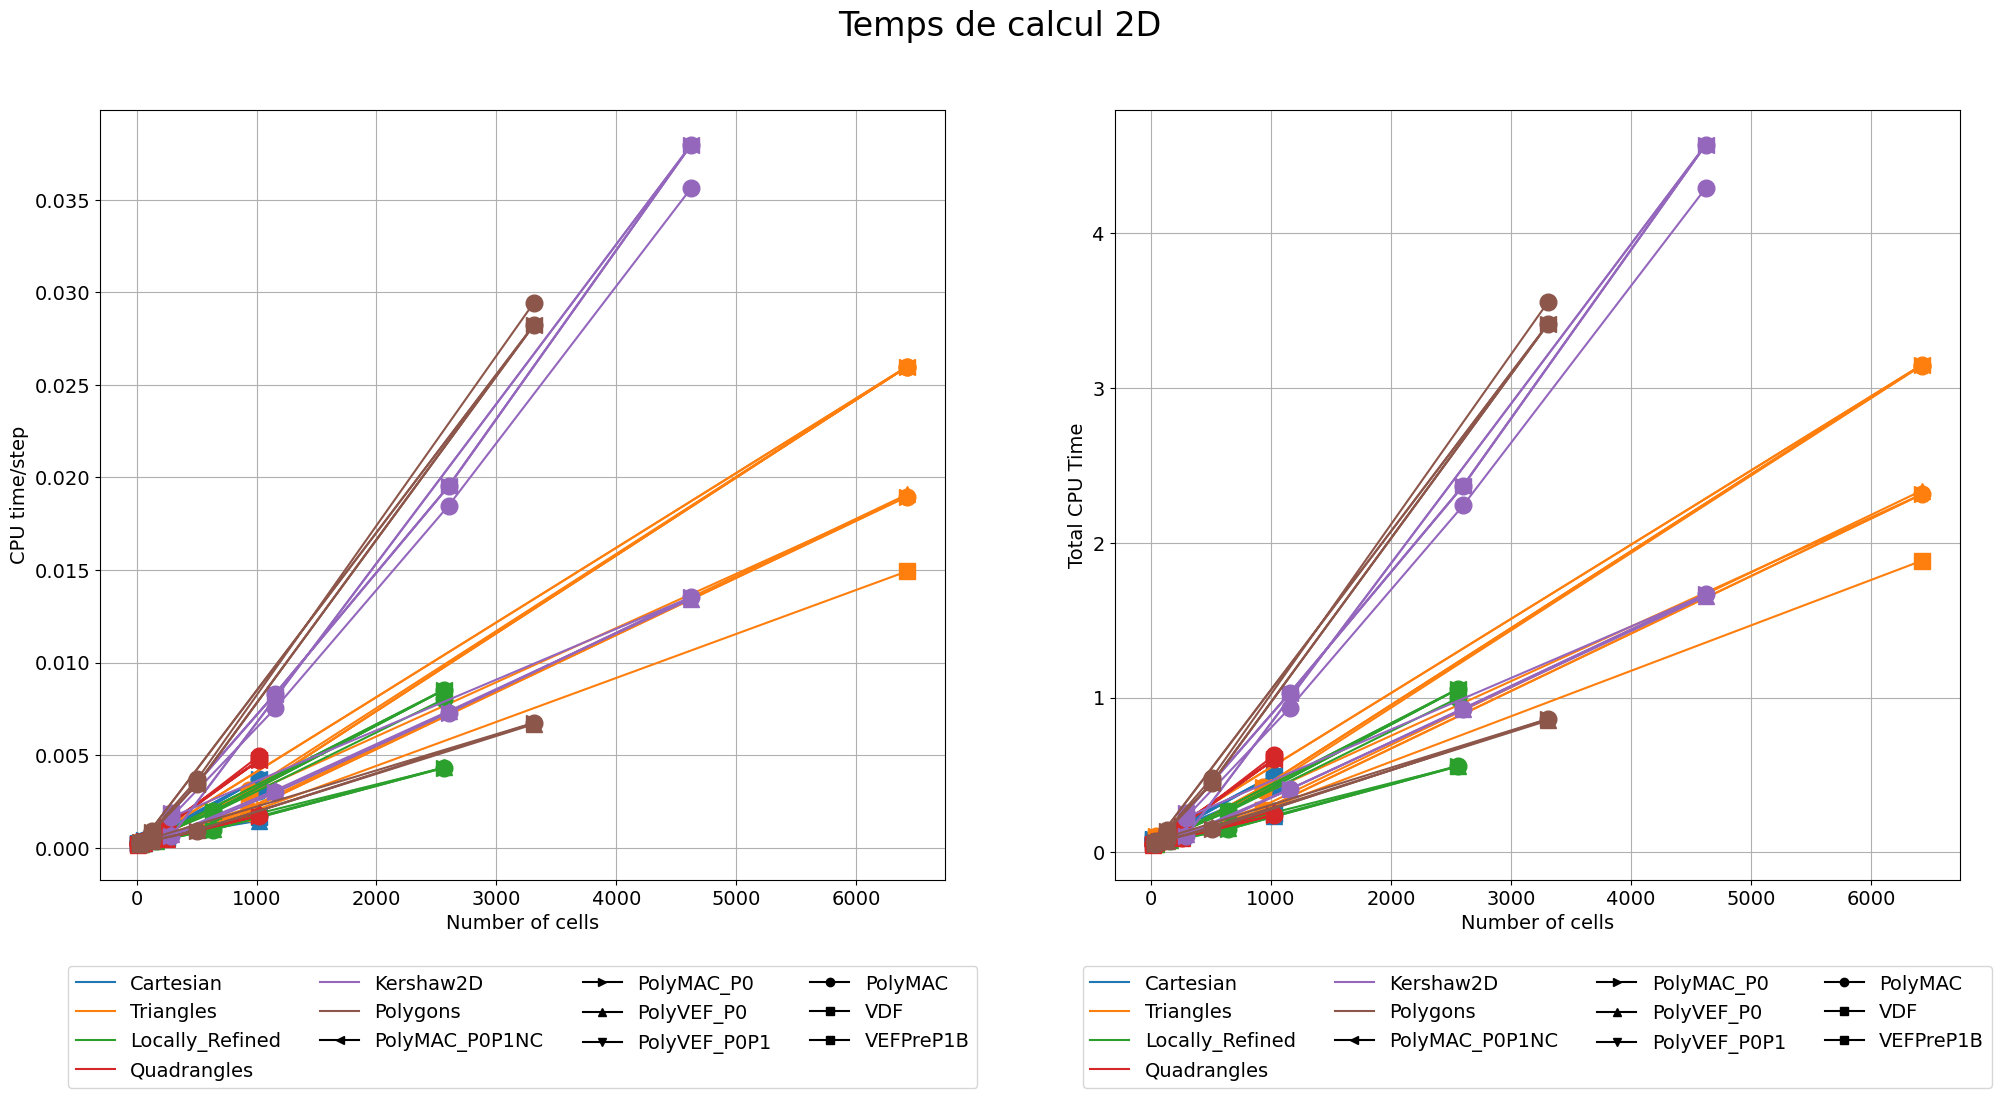

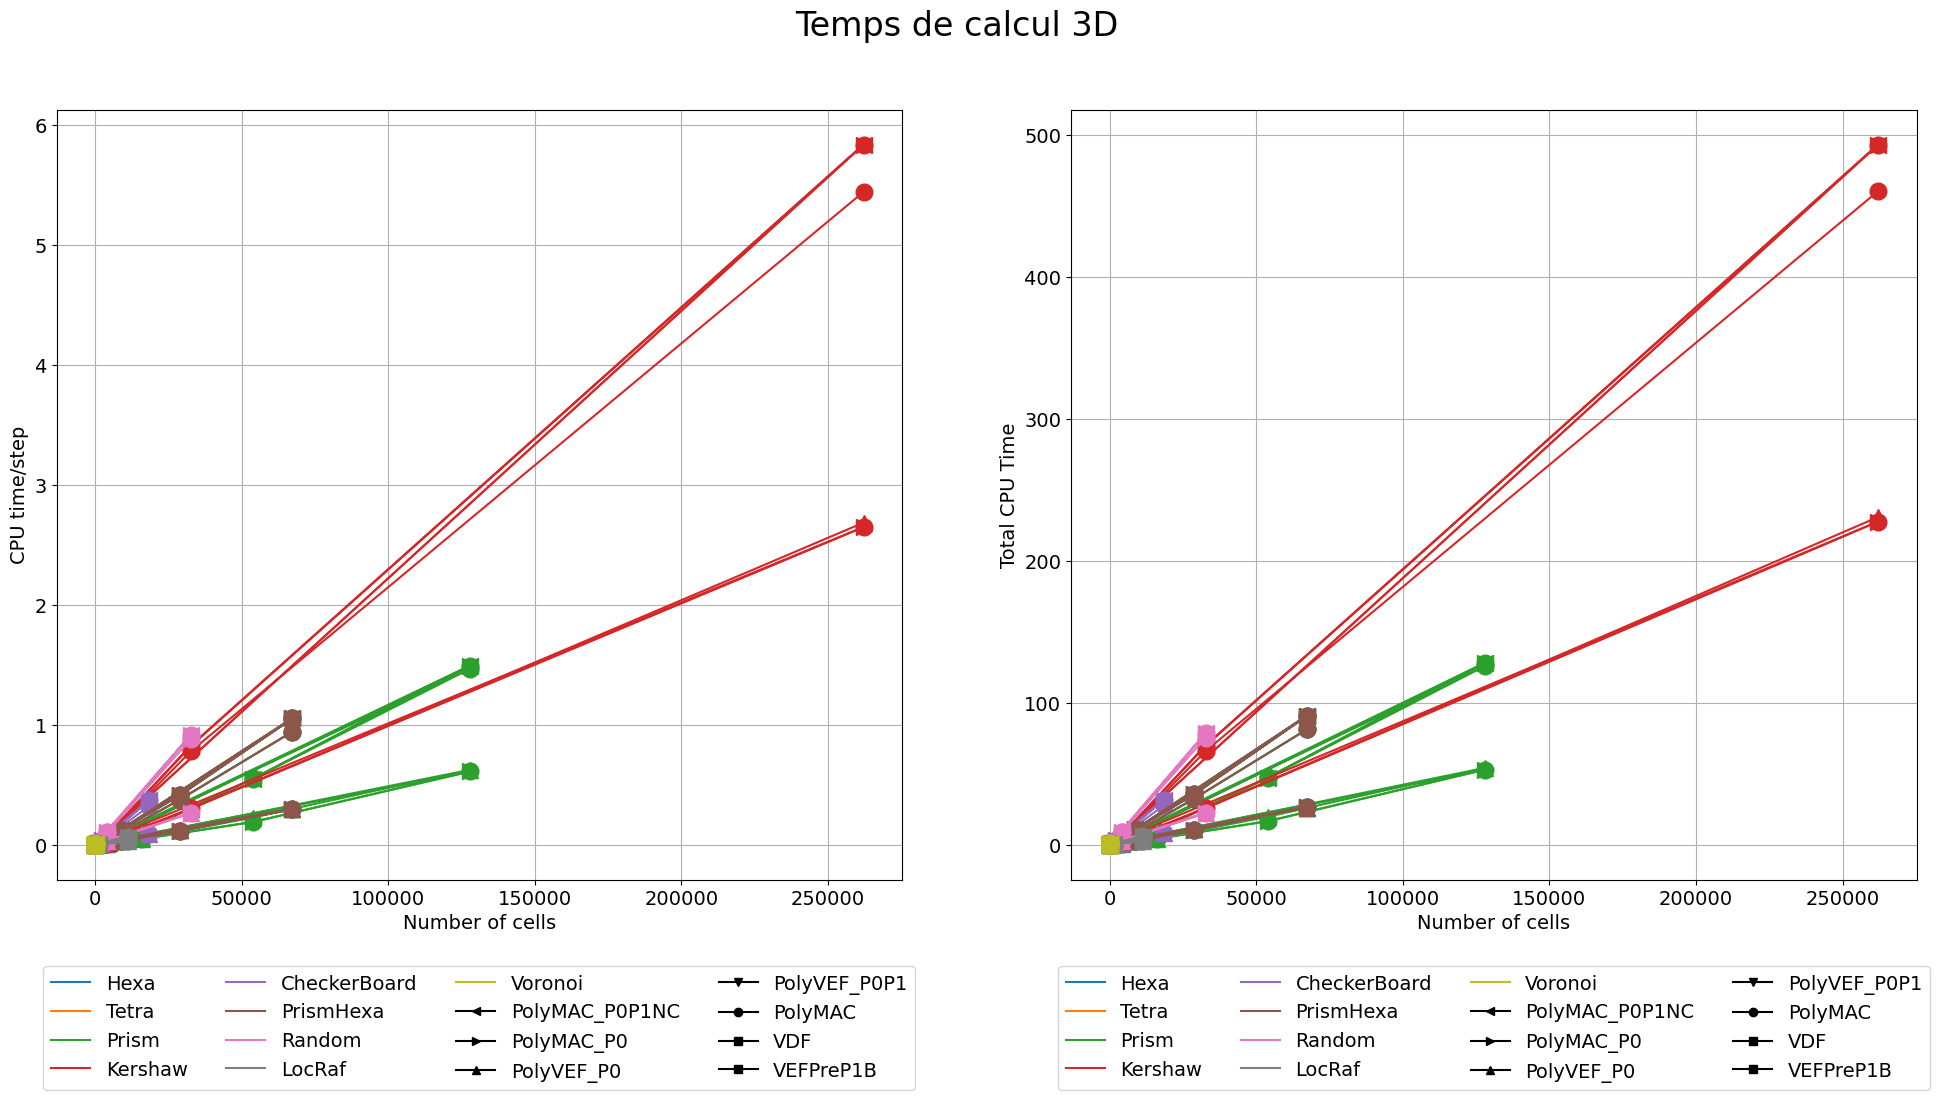

In [3]:
from trustutils import plot
import matplotlib.colors as mcolors
import pandas as pd
from matplotlib.lines import Line2D
c = list(mcolors.TABLEAU_COLORS.keys())
linestyle = {"PolyMAC_P0P1NC": ("-", "<"), "PolyMAC_P0" : ("-", ">"), "PolyVEF_P0" : ("-", "^"), "PolyVEF_P0P1" : ("-", "v"), "PolyMAC" : ("-", "o"), "VDF" : ("-", "s"), "VEFPreP1B" : ("-", "s"), }

lines_and_markers = {dim : [Line2D([0], [0], color=c[k]) for k, _ in enumerate(dic.items())] for dim, dic in [(2, m2d), (3, m3d)]}
for i in [2, 3]: lines_and_markers[i] += [Line2D([0], [0], color="black", marker=m, linestyle=s) for _, (s, m) in linestyle.items()]
names_in_legend = {dim : list(dic.keys()) for dim, dic in [(2, m2d), (3, m3d)]}
for i in [2, 3]: names_in_legend[i] += list(linestyle.keys())

def make_custom_legend(graph, dim):
    try:
        for ax in graph.axs:
            ax.legend(lines_and_markers[dim], names_in_legend[dim], loc='upper center', ncol=4, bbox_to_anchor=(0.5, -0.1))
    except:
        graph.subplot.legend(lines_and_markers[dim], names_in_legend[dim], loc='upper center', ncol=4, bbox_to_anchor=(0.5, -0.1))

df = run.tablePerf()

for dim, dic in [(2, m2d), (3, m3d)]:
    a = plot.Graph(f"Temps de calcul {dim}D", nY=2)
    for k, (m, (dis, _)) in enumerate(dic.items()):
        df_m = df[df.index.map(lambda s: m in s)]
        for d in dis:
            df_md = df_m[df_m.index.map(lambda s: d in s)]
            for i, metrique in enumerate(["CPU time/step", "Total CPU Time"]):
                a.addPlot(i)
                nbc = [float(n) for n in df_md["number of cells"].tolist()]
                tcpu = [float(t) for t in df_md[metrique].tolist()]
                a.add(nbc, tcpu, label=None, color=c[k], linestyle=linestyle[d][0], marker=linestyle[d][1], markersize=12)
                a.label(f"Number of cells", metrique)
    make_custom_legend(a, dim)


## Ordres de convergence

,VDF,PolyMAC_P0P1NC,PolyMAC_P0,PolyMAC,PolyVEF_P0,VEFPreP1B
Cartesian,1.88,1.88,1.88,1.88,1.88,NaN
Triangles,NaN,1.81,1.93,1.81,1.93,2.30
Locally_Refined,NaN,1.90,1.85,1.80,1.85,NaN
Quadrangles,NaN,2.53,2.57,2.49,2.57,NaN
Kershaw2D,NaN,1.84,1.73,1.84,1.73,NaN
Polygons,NaN,2.90,2.90,2.89,2.90,NaN
Hexa,NaN,2.13,2.13,2.13,2.13,NaN
Tetra,NaN,1.88,1.92,1.73,1.92,1.83
Prism,NaN,1.70,2.06,1.75,2.06,NaN
Kershaw,NaN,1.24,0.97,1.30,0.97,NaN


\begin{tabular}{lllllll}
\toprule
 & VDF & PolyMAC_P0P1NC & PolyMAC_P0 & PolyMAC & PolyVEF_P0 & VEFPreP1B \\
\midrule
Cartesian & 1.88 & 1.88 & 1.88 & 1.88 & 1.88 & NaN \\
Triangles & NaN & 1.81 & 1.93 & 1.81 & 1.93 & 2.30 \\
Locally_Refined & NaN & 1.90 & 1.85 & 1.80 & 1.85 & NaN \\
Quadrangles & NaN & 2.53 & 2.57 & 2.49 & 2.57 & NaN \\
Kershaw2D & NaN & 1.84 & 1.73 & 1.84 & 1.73 & NaN \\
Polygons & NaN & 2.90 & 2.90 & 2.89 & 2.90 & NaN \\
Hexa & NaN & 2.13 & 2.13 & 2.13 & 2.13 & NaN \\
Tetra & NaN & 1.88 & 1.92 & 1.73 & 1.92 & 1.83 \\
Prism & NaN & 1.70 & 2.06 & 1.75 & 2.06 & NaN \\
Kershaw & NaN & 1.24 & 0.97 & 1.30 & 0.97 & NaN \\
CheckerBoard & NaN & 2.67 & 1.56 & 2.26 & 1.56 & NaN \\
PrismHexa & NaN & 1.97 & 2.10 & 2.00 & 2.10 & NaN \\
Random & NaN & 0.82 & 1.10 & 0.87 & 1.10 & NaN \\
LocRaf & NaN & 2.16 & 2.04 & 2.04 & 2.04 & NaN \\
Voronoi & NaN & 2.20 & 1.76 & 2.42 & 1.76 & NaN \\
\bottomrule
\end{tabular}



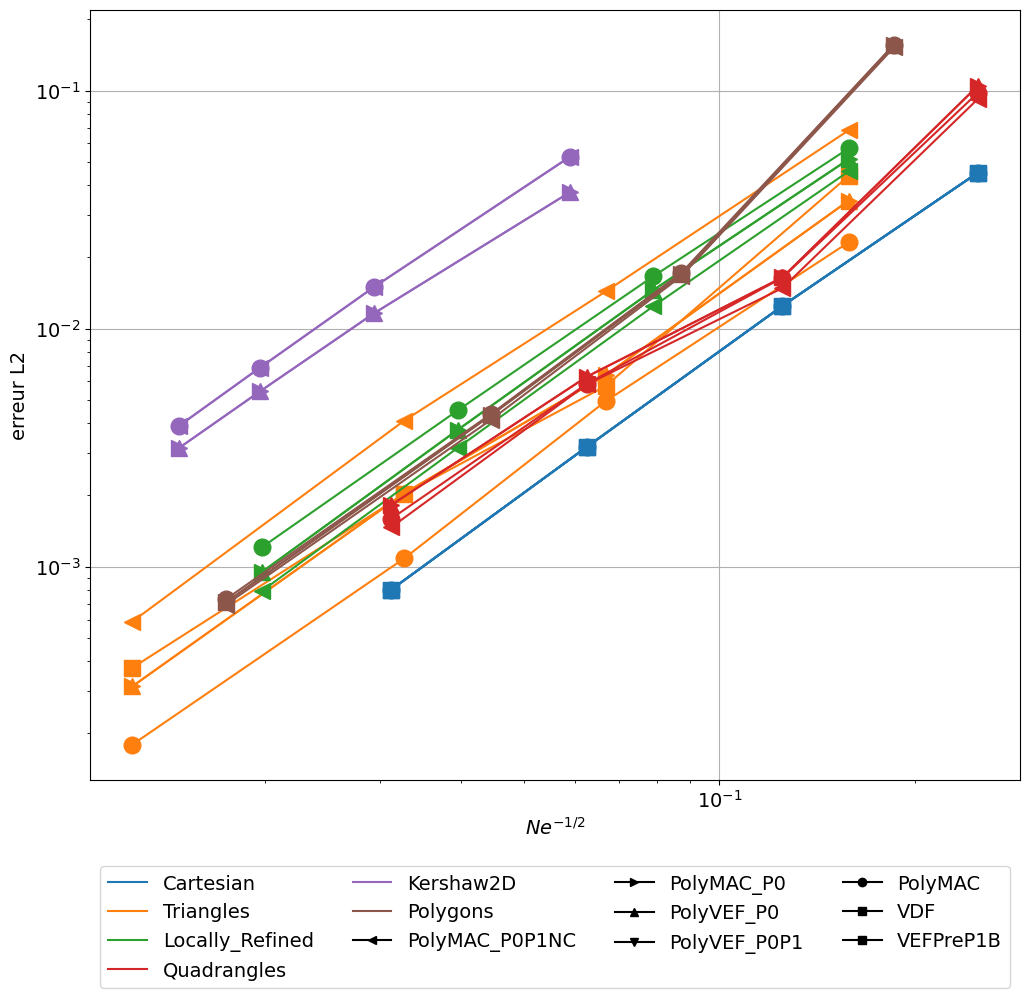

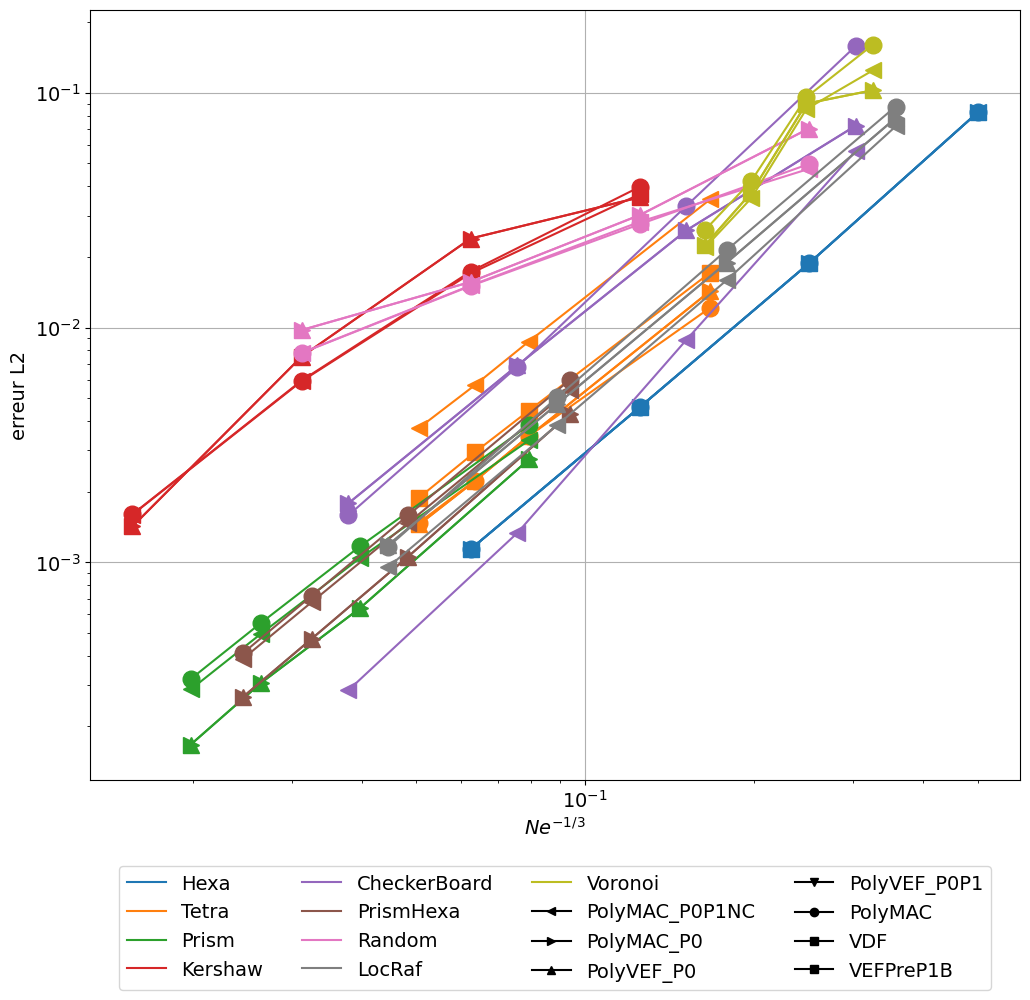

In [7]:
import numpy as np
from scipy.optimize import curve_fit

def func(x, a, b): return a * x ** b
orders = {}
for dim, dic in [(2, m2d), (3, m3d)]:
    a = plot.Graph("")
    for k, (m, (dis, ns)) in enumerate(dic.items()):
        for d in dis:
            x_ = plot.loadText(f"{m}/{d}/conv_glob")
            x, y = (np.power(x_[0], -1.0 / dim)).tolist(), x_[1].tolist()
            try: (_, b), _ = curve_fit(func, x, y)
            except: b = 0
            if m in orders:
                orders[m][d] = f"{b:.2f}"
            else:
                orders[m] = {d : f"{b:.2f}"}
            a.add(x, y, label=None, color=c[k], linestyle=linestyle[d][0], marker=linestyle[d][1], markersize=12, title=f"Maillages {dim}D")

    a.label(f"$Ne^{{-1/{dim}}}$","erreur L2")
    a.scale(xscale='log',yscale='log')
    make_custom_legend(a, dim)

df_orders = pd.DataFrame.from_dict(orders).T
display(df_orders)
print(df_orders.to_latex())

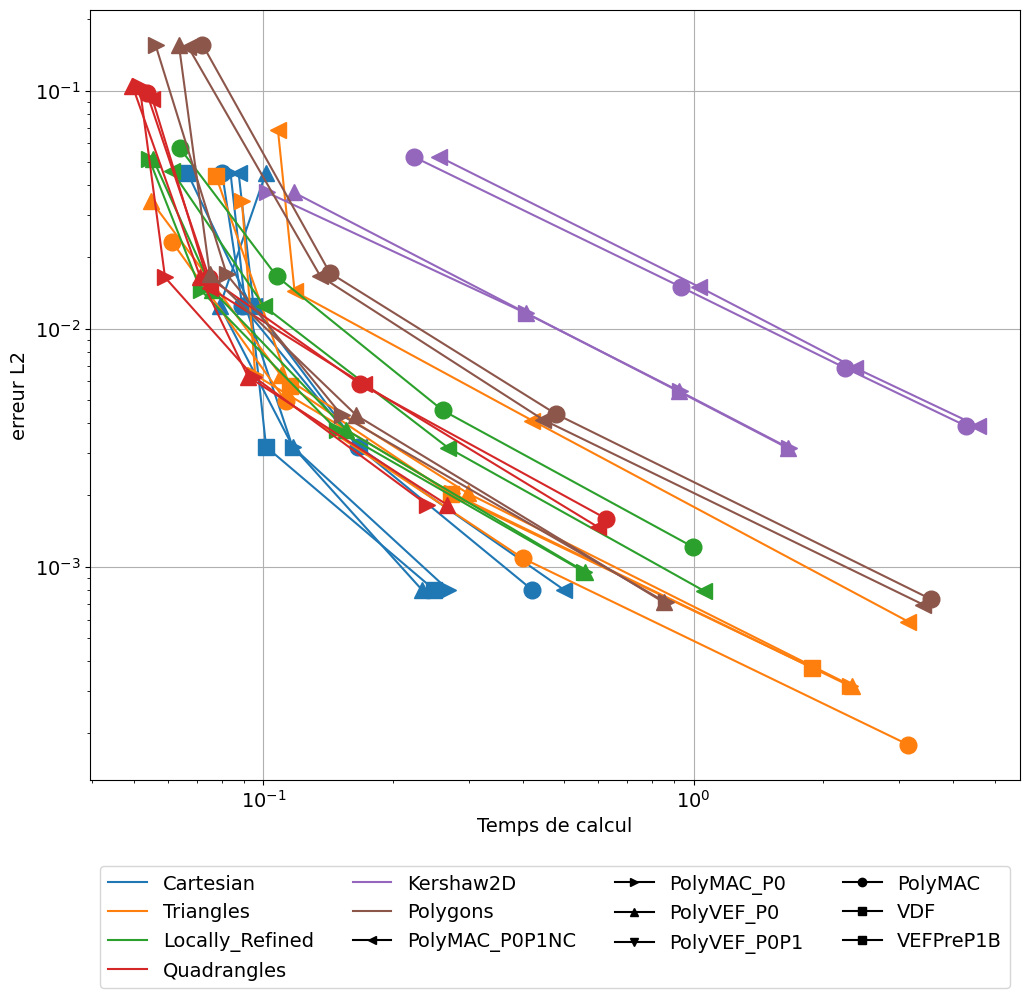

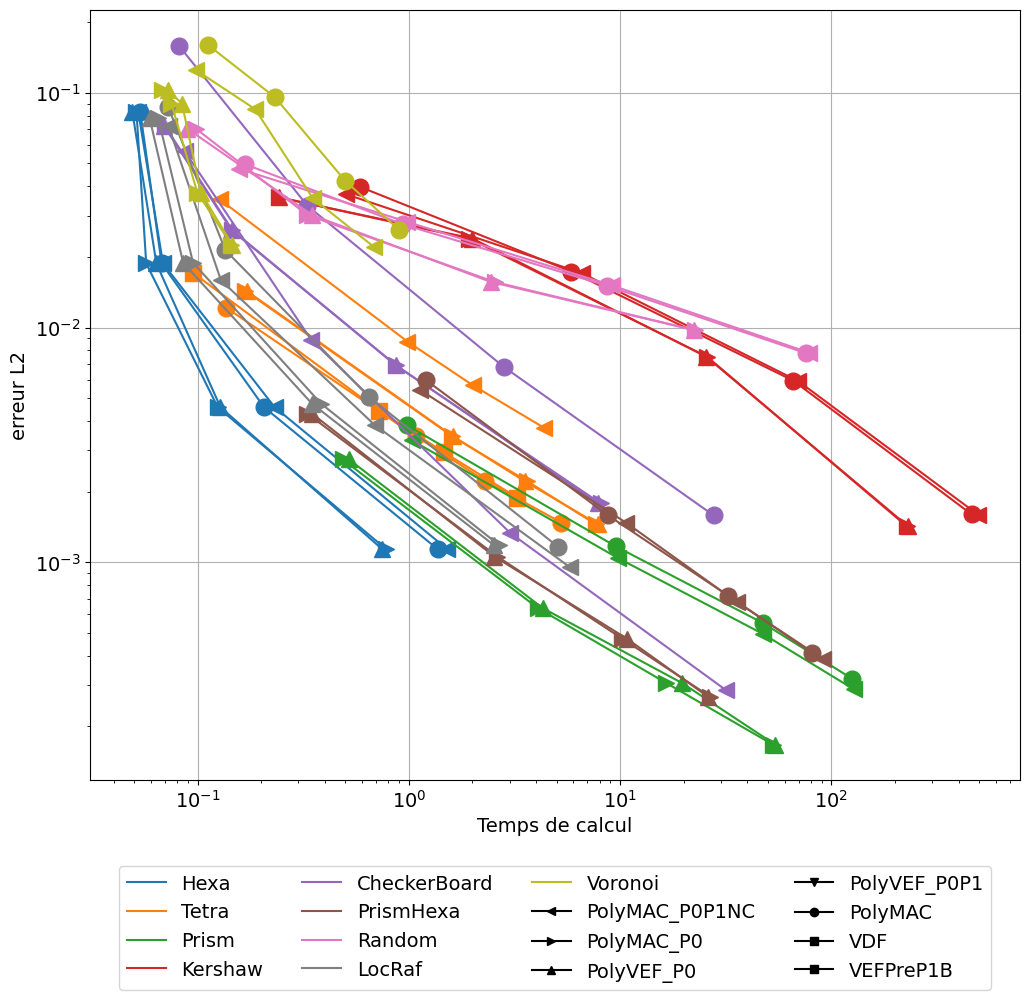

In [5]:
for dim, dic in [(2, m2d), (3, m3d)]:
    a = plot.Graph("")
    for k, (m, (dis, _)) in enumerate(dic.items()):
        for d in dis:
            x_ = plot.loadText(f"{m}/{d}/conv_glob")
            x, y = x_[2].tolist(), x_[1].tolist()
            a.add(x, y, label=None, color=c[k], linestyle=linestyle[d][0], marker=linestyle[d][1], markersize=12, title=f"Maillages {dim}D")

    a.label(f"Temps de calcul","erreur L2")
    a.scale(xscale='log',yscale='log')
    make_custom_legend(a, dim)
